# Comparing Data Sets.
____

In [1]:
from pathlib import Path
from microlive.imports import *
from microlive import microscopy as mi
current_dir = Path().resolve()
parent_dir = current_dir.parents[1]
main_dir = Path().resolve().parent
one_drive_dir = mi.Utilities.get_one_drive_dir()
import sys
repo_root = Path().resolve().parents[2]  # Go up to cof_paper/
sys.path.insert(0, str(repo_root))

import utilities as ld
importlib.reload(ld)


<module 'utilities' from '/Users/nzlab-la/Desktop/cof_paper/utilities/__init__.py'>

In [2]:
one_drive_dir

PosixPath('/Users/nzlab-la/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver')

## Loading data and strings for subclassification
___

In [3]:
# Loading data
        #RMS External Drive Location:    'E:/Co-translational folding (CoF) paper/Fig 2_Fast coTFT minitrack analysis'
        #Ning Zhao OneDrive Location:    '...General - Zhao (NZ) Lab\Zhao lab shared folder\Our papers\co-translational folding paper\Fig 2\Fig 2_Fast coTFT minitrack analysis'
#dataframes_dir = Path('E:/Co-translational folding (CoF) paper/Fig 2_Fast coTFT minitrack analysis')
dataframes_dir = one_drive_dir / 'General - Zhao (NZ) Lab' / 'Zhao lab shared folder' / 'Our papers' / 'co-translational folding paper' / 'Fig 2' / 'Fig 2_Slow coTFT minitrack analysis'
# Average Folder Substrings

list_folder_substring_to_avoid = None


save_dir = current_dir.joinpath('temp_results_slow')
save_dir.mkdir(parents=True, exist_ok=True)

# Individual day Folder Substrings
plot_individual_days = True     # Set to False to skip plotting individual experiment days and plot the overall average.

list_folder_substrings, list_names = ld.get_folder_substrings_and_names(
    dataframes_dir, 
    process_individual_days=plot_individual_days,
)
print(list_folder_substrings)
print(list_names)


Found 5 plasmids in 171 folders
  pNZ370: 3 experiment(s)
  pRS032: 4 experiment(s)
  pNZ389: 3 experiment(s)
  pNZ388: 3 experiment(s)
  pNZ396: 2 experiment(s)
['20260121 pNZ370', '20260304 pNZ370', '20260306 pNZ370', '20260115 pRS032', '20260121 pRS032', '20260205__pRS012_pRS032', '20260205_pRS012_pRS032', '20260304 pNZ396', '20260306 pNZ396', '20260112 pNZ389', '20260115 pNZ389', '20260123 pNZ389', '20260112 pNZ388', '20260115 pNZ388', '20260123 pNZ388']
['6uv-1', '6uv-2', '6uv-3', '4uv-1', '4uv-2', '4uv-3', '4uv-4', '3uv-1', '3uv-2', '2uv-1', '2uv-2', '2uv-3', '1uv-1', '1uv-2', '1uv-3']


## Loading the data
____

In [4]:
data_dict = ld.aggregate_folder_data(dataframes_dir,list_folder_substrings,
            list_folder_substring_to_avoid,list_folder_substring_second_condition=None,
            show_file_names=True, verbose= False)

Loaded results_20260121 pNZ370_pRS012_JF646 6hr Tfx_Series001 (2 channels)
Loaded results_20260121 pNZ370_pRS012_JF646 6hr Tfx_Series002 (2 channels)
Loaded results_20260121 pNZ370_pRS012_JF646 6hr Tfx_Series003 (2 channels)
Loaded results_20260121 pNZ370_pRS012_JF646 6hr Tfx_Series004 (2 channels)
Loaded results_20260121 pNZ370_pRS012_JF646 6hr Tfx_Series005 (2 channels)
Loaded results_20260121 pNZ370_pRS012_JF646 6hr Tfx_Series006 (2 channels)
Loaded results_20260121 pNZ370_pRS012_JF646 6hr Tfx_Series007 (2 channels)
Loaded results_20260121 pNZ370_pRS012_JF646 6hr Tfx_Series008 (2 channels)
Loaded results_20260121 pNZ370_pRS012_JF646 6hr Tfx_Series009 (2 channels)
Loaded results_20260121 pNZ370_pRS012_JF646 6hr Tfx_Series010 (2 channels)
Loaded results_20260121 pNZ370_pRS012_JF646 6hr Tfx_Series012 (2 channels)
Loaded results_20260304 pNZ370_pRS012_JF646 6hr Tfx_Series001 (2 channels)
Loaded results_20260304 pNZ370_pRS012_JF646 6hr Tfx_Series002 (2 channels)
Loaded results_20260304 p

## Plotting Configuration
___

In [5]:
# ── Plotting Configuration ─────────────────────────────────
PLOT_CONFIG = dict(
    figsize       = (7, 4),
    tick_size     = 10,
    swarm_color   = 'black',
    show_stats    = False,
    only_significant = True,
    max_percentile_significance = 99.5,
)

SAVE_DIR = save_dir  # Defined in data config above; set to None to skip saving


## Plotting data
___

In [6]:
for key in data_dict.keys():
    print(key)


directories
int_ch_0
int_ch_1
snr_ch_0
snr_ch_1
spot_size_ch_0
spot_size_ch_1
total_spot_int_ch_0
total_spot_int_ch_1
spot_amplitude_ch_0
spot_amplitude_ch_1
spot_sigma_ch_0
spot_sigma_ch_1
number_spots
frames
number_of_color_channels
average_number_spots
efficiency_ml
efficiency_manual


## Calculating Folding Efficiency using ML method

___

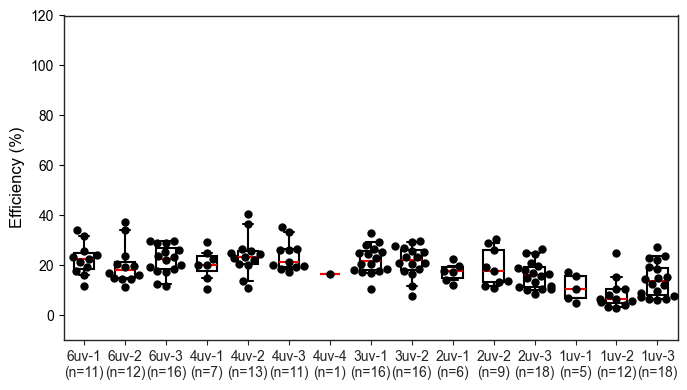

<Axes: ylabel='Efficiency (%)'>

In [7]:
ld.plot_swarm_plot(
    data_dict['efficiency_manual'], list_names,
    y_label='Efficiency (%)',
    y_lim=(-10, 120),
    plot_name='efficiency_verification',
    save_dir=SAVE_DIR,
    **PLOT_CONFIG,
)


In [8]:
ld.export_efficiency_to_excel(
    data_dict, 
    list_folder_substrings,  
    list_names, 
    efficiency_key="efficiency_manual",
    save_path= 'Dark_mCh_Cells_slow.xlsx',
)


Saved efficiency data to: Dark_mCh_Cells_slow.xlsx
  15 conditions, 18 max cells
    Col 1: 20260121 | pUB-RBsmHA-6xGFPuv-24xMS2
    Col 2: 20260304 | pUB-RBsmHA-6xGFPuv-24xMS2
    Col 3: 20260306 | pUB-RBsmHA-6xGFPuv-24xMS2
    Col 4: 20260115 | pUB-RBsmHA-4xGFPuv-2xmCh-24xMS2
    Col 5: 20260121 | pUB-RBsmHA-4xGFPuv-2xmCh-24xMS2
    Col 6: 20260205 | pUB-RBsmHA-4xGFPuv-2xmCh-24xMS2
    Col 7: 20260205 | pUB-RBsmHA-4xGFPuv-2xmCh-24xMS2
    Col 8: 20260304 | pUB-RBsmHA-3xGFPuv-3xmCh-24xMS2
    Col 9: 20260306 | pUB-RBsmHA-3xGFPuv-3xmCh-24xMS2
    Col 10: 20260112 | pUB-RBsmHA-2xGFPuv-4xmCh-24xMS2
    Col 11: 20260115 | pUB-RBsmHA-2xGFPuv-4xmCh-24xMS2
    Col 12: 20260123 | pUB-RBsmHA-2xGFPuv-4xmCh-24xMS2
    Col 13: 20260112 | pUB-RBsmHA-1xGFPuv-5xmCh-24xMS2
    Col 14: 20260115 | pUB-RBsmHA-1xGFPuv-5xmCh-24xMS2
    Col 15: 20260123 | pUB-RBsmHA-1xGFPuv-5xmCh-24xMS2


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,GFP Fast-mCherry Reporters,,,,,,,,,,,,,,,
1,Date,20260121,20260304,20260306,20260115,20260121,20260205,20260205,20260304,20260306,20260112,20260115,20260123,20260112,20260115,20260123
2,Reporter Variant,pUB-RBsmHA-6xGFPuv-24xMS2,pUB-RBsmHA-6xGFPuv-24xMS2,pUB-RBsmHA-6xGFPuv-24xMS2,pUB-RBsmHA-4xGFPuv-2xmCh-24xMS2,pUB-RBsmHA-4xGFPuv-2xmCh-24xMS2,pUB-RBsmHA-4xGFPuv-2xmCh-24xMS2,pUB-RBsmHA-4xGFPuv-2xmCh-24xMS2,pUB-RBsmHA-3xGFPuv-3xmCh-24xMS2,pUB-RBsmHA-3xGFPuv-3xmCh-24xMS2,pUB-RBsmHA-2xGFPuv-4xmCh-24xMS2,pUB-RBsmHA-2xGFPuv-4xmCh-24xMS2,pUB-RBsmHA-2xGFPuv-4xmCh-24xMS2,pUB-RBsmHA-1xGFPuv-5xmCh-24xMS2,pUB-RBsmHA-1xGFPuv-5xmCh-24xMS2,pUB-RBsmHA-1xGFPuv-5xmCh-24xMS2
3,,,,,,,,,,,,,,,,
4,CoF Efficiency,ML 0.5,ML 0.5,ML 0.5,ML 0.5,ML 0.5,ML 0.5,ML 0.5,ML 0.5,ML 0.5,ML 0.5,ML 0.5,ML 0.5,ML 0.5,ML 0.5,ML 0.5
5,Cell 1,16.22,23.53,17.11,22.41,36.57,26.09,16.3,28.21,20.75,13.98,11.48,15.69,15.57,3.97,11.96
6,Cell 2,11.76,19.15,11.72,20.12,20.0,33.33,,10.64,20.59,17.71,28.81,18.67,5.04,10.29,6.33
7,Cell 3,19.35,11.11,17.84,25.0,20.39,26.47,,26.67,26.98,22.3,26.21,24.71,6.76,2.67,14.49
8,Cell 4,31.77,20.5,26.0,20.0,13.71,17.11,,17.54,29.79,17.43,13.85,13.33,17.22,5.8,7.14
9,Cell 5,17.65,19.66,12.33,15.0,23.15,21.1,,29.41,29.17,19.76,19.35,11.48,10.53,6.4,18.42


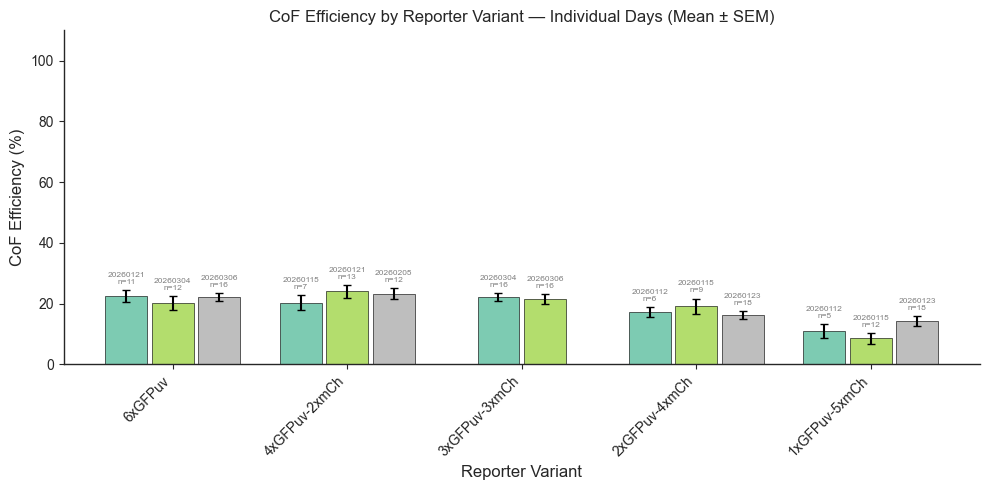


6xGFPuv:
  20260121: 22.5 ± 1.9% (n=11)
  20260304: 20.2 ± 2.3% (n=12)
  20260306: 22.2 ± 1.5% (n=16)

4xGFPuv-2xmCh:
  20260115: 20.3 ± 2.3% (n=7)
  20260121: 24.0 ± 2.2% (n=13)
  20260205: 23.3 ± 1.8% (n=12)

3xGFPuv-3xmCh:
  20260304: 22.2 ± 1.4% (n=16)
  20260306: 21.6 ± 1.6% (n=16)

2xGFPuv-4xmCh:
  20260112: 17.2 ± 1.5% (n=6)
  20260115: 19.1 ± 2.5% (n=9)
  20260123: 16.2 ± 1.3% (n=18)

1xGFPuv-5xmCh:
  20260112: 11.0 ± 2.4% (n=5)
  20260115: 8.6 ± 1.8% (n=12)
  20260123: 14.2 ± 1.6% (n=18)


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

# --- Load the Excel file ---
excel_path =  'Dark_mCh_Cells_slow.xlsx'
raw = pd.read_excel(excel_path, header=None)

# Parse structure
dates = raw.iloc[1, 1:].values
reporters = raw.iloc[2, 1:].values
data_start_row = 5

# Group cell values by (reporter, date)
variant_day_data = OrderedDict()  # key = reporter, value = OrderedDict of date → [values]
for col_idx in range(1, raw.shape[1]):
    reporter = reporters[col_idx - 1]
    date = str(dates[col_idx - 1]) if pd.notna(dates[col_idx - 1]) else 'unknown'
    if pd.isna(reporter) or reporter == '':
        continue
    vals = pd.to_numeric(raw.iloc[data_start_row:, col_idx], errors='coerce').dropna().values
    if reporter not in variant_day_data:
        variant_day_data[reporter] = OrderedDict()
    if date not in variant_day_data[reporter]:
        variant_day_data[reporter][date] = []
    variant_day_data[reporter][date].extend(vals)

# Short labels
def shorten(lbl):
    return lbl.replace('pUB-RBsmHA-', '').replace('-24xMS2', '')

# --- Plot ---
variants = list(variant_day_data.keys())
max_days = max(len(days) for days in variant_day_data.values())

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Set2(np.linspace(0, 1, max_days))
bar_width = 0.8 / max_days

for var_idx, (variant, day_dict) in enumerate(variant_day_data.items()):
    for day_idx, (date, vals) in enumerate(day_dict.items()):
        mean = np.mean(vals)
        sem = np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0
        x = var_idx + (day_idx - len(day_dict)/2 + 0.5) * bar_width
        bar = ax.bar(x, mean, width=bar_width * 0.9, yerr=sem, capsize=3,
                     color=colors[day_idx], edgecolor='black', alpha=0.85)
        ax.text(x, mean + sem + 2, f'{date}\nn={len(vals)}', 
                ha='center', fontsize=6, color='gray', rotation=0)

ax.set_xticks(range(len(variants)))
ax.set_xticklabels([shorten(v) for v in variants], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('CoF Efficiency (%)', fontsize=12)
ax.set_xlabel('Reporter Variant', fontsize=12)
ax.set_title('CoF Efficiency by Reporter Variant — Individual Days (Mean ± SEM)', fontsize=12)
ax.set_ylim(0, 110)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Print summary
for variant, day_dict in variant_day_data.items():
    print(f"\n{shorten(variant)}:")
    for date, vals in day_dict.items():
        m = np.mean(vals)
        s = np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0
        print(f"  {date}: {m:.1f} ± {s:.1f}% (n={len(vals)})")
